In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Loading

In [2]:
ds = load_dataset('thiru1711/Financial_Transactions')

splits = [ds[split].to_pandas() for split in ds.keys()]
raw_df = pd.concat(splits, ignore_index=True)
print(f'Total rows : {len(raw_df):,}')
print(f'Columns    : {list(raw_df.columns)}')
raw_df.info()



Total rows : 13,305,915
Columns    : ['transaction_id', 'date', 'card_id', 'amount', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'errors', 'is_fraud', 'card_brand', 'card_type', 'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web', 'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'mcc_description']
<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 37 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         str           
 1   date                   datetime64[ns]
 2   card_id                str           
 3   amount                 float32       
 4   use_chip               str           
 5   merchant_id          

In [3]:
# filter by mcc 5411

new_df = raw_df[raw_df['mcc'] == 5411].copy()

# find number of merchants with months with less than 5 transactions in the month
new_df['year'] = new_df['date'].dt.to_period('Y')
new_df['month'] = new_df['date'].dt.to_period('M')
txn_counts = new_df.groupby(['merchant_id', 'year', 'month']).size().reset_index(name='txn_count')
low_txn_months = txn_counts[txn_counts['txn_count'] < 5]
num_merchants_low_txn = low_txn_months['merchant_id'].nunique()
print(f'Number of merchants with at least one month with less than 5 transactions: {num_merchants_low_txn}')

Number of merchants with at least one month with less than 5 transactions: 0


In [4]:
df = raw_df.copy()

# Drop columns not needed
drop_cols = [
    # PII/Security Fields
    'card_number', 'cvv', 'expires', 'address',

    # Cardholder Demographics
    'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
    'latitude', 'longitude', 'per_capita_income', 'yearly_income',
    'total_debt', 'credit_score', 'num_credit_cards','credit_limit',

    # Account Metadata
    'card_id', 'acct_open_date', 'year_pin_last_changed',
    'card_on_dark_web', 'num_cards_issued',

    # Geographical features
    'merchant_state', 'zip', 'merchant_city', 'has_chip'
]

df = df.drop(columns=drop_cols)

# Parse date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Coerce numeric columns
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['mcc']    = pd.to_numeric(df['mcc'],    errors='coerce').astype('Int64')

# Standardise card type label
df['card_type'] = df['card_type'].str.strip().str.lower()

# Drop rows with errors flagged
if 'errors' in df.columns:
    df = df[df['errors'].isna() | (df['errors'] == '')]
    
# drop fraud rows (if any)
if 'is_fraud' in df.columns:
    df = df[df['is_fraud'] == 0]

# Keep only Visa / Mastercard (match cost-table coverage)
df = df[df['card_brand'].str.lower().isin(['visa', 'mastercard'])]

# drop rows with negative or zero amount
df = df[df['amount'] > 0]

df = df.dropna(subset=['amount', 'mcc', 'date']).reset_index(drop=True)


# renme card_brand to card_type
df['card_type'] = df['card_type'].str.strip().str.lower()
df['card_network'] = df['card_brand'].str.strip().str.lower()
df = df.drop(columns=['card_brand'])

df['card_type'] = df['card_type'].replace('debit (prepaid)', 'prepaid')

df['card_type'] = df['card_type'].str.strip().str.lower()
df['card_network'] = df['card_network'].str.strip().str.lower()

print(f'Rows after cleaning: {len(df):,}')

Rows after cleaning: 11,313,086


In [5]:
print(f"Remaining columns")
for feature_name, feature_type in df.dtypes.items():
    print(f"Column: {feature_name}, Data Type: {feature_type}")
    
print(df['card_network'].value_counts())

print(df['card_type'].value_counts())

Remaining columns
Column: transaction_id, Data Type: str
Column: date, Data Type: datetime64[ns]
Column: amount, Data Type: float32
Column: use_chip, Data Type: str
Column: merchant_id, Data Type: int64
Column: mcc, Data Type: Int64
Column: errors, Data Type: str
Column: is_fraud, Data Type: int64
Column: card_type, Data Type: str
Column: mcc_description, Data Type: str
Column: card_network, Data Type: str
card_network
mastercard    6679046
visa          4634040
Name: count, dtype: int64
card_type
debit      7727078
credit     2717315
prepaid     868693
Name: count, dtype: int64


In [6]:
cost_type_df = pd.read_csv('cost_type_id_18feb.csv')
cost_type_df['card_network'] = cost_type_df['card_network'].str.strip().str.lower()
cost_type_df['card_type'] = cost_type_df['card_brand'].str.strip().str.lower()
cost_type_df.drop(columns=['card_brand'], inplace=True)

cost_type_df = cost_type_df.drop(columns=['Unnamed: 13'], errors='ignore')


In [7]:
# Ensure mcc is same type in both dataframes
# df_5411['mcc'] = df_5411['mcc'].astype(float)
cost_type_df['mcc'] = pd.to_numeric(cost_type_df['mcc'], errors='coerce')

df_filtered = df[df['card_network'].isin(['visa', 'mastercard'])]

df_filtered['card_network'] = df_filtered['card_network'].str.strip().str.lower()
df_filtered['card_type'] = df_filtered['card_type'].str.strip().str.lower()

print(f"Unique card_network in df_filtered: {df_filtered['card_network'].unique()}")
print(f"Unique card_type in df_filtered: {df_filtered['card_type'].unique()}")

Unique card_network in df_filtered: <ArrowStringArray>
['mastercard', 'visa']
Length: 2, dtype: str
Unique card_type in df_filtered: <ArrowStringArray>
['credit', 'debit', 'prepaid']
Length: 3, dtype: str


In [8]:


# drop cost_type_id from filtered df if exists to avoid confusion during merge
if 'cost_type_ID' in df_filtered.columns:
    df_filtered = df_filtered.drop('cost_type_ID', axis=1)

# Separate rules
cost_general = cost_type_df[cost_type_df['mcc'].isna()].copy().dropna(subset=['card_type', 'card_network'])
cost_specific = cost_type_df[cost_type_df['mcc'].notna()].copy().dropna(subset=['card_type', 'card_network', 'mcc'])

print(f"General rules: {len(cost_general)}")
print(f"Specific rules: {len(cost_specific)}")

# Process small (<=5): general rules
df_small = df_filtered[df_filtered['amount'] <= 5].merge(
    cost_general,
    left_on=['card_type', 'card_network'],
    right_on=['card_type', 'card_network'],
    how='left',
    suffixes=('', '_cost')
)

# print(df_small.head(5))

df_small = df_small[
    (df_small['amount'] >= df_small['min_transaction_amt']) &
    (df_small['amount'] <= df_small['max_transaction_amt']) &
    (df_small['cost_type_ID'].notna())
]

df_small = df_small.sort_values('transaction_id').drop_duplicates('transaction_id', keep='first')


# Process large (>5): mcc-specific rules
df_large = df_filtered[df_filtered['amount'] > 5].merge(
    cost_specific,
    left_on=['card_type', 'card_network', 'mcc'],
    right_on=['card_type', 'card_network', 'mcc'],
    how='left',
    suffixes=('', '_cost')
)
df_large = df_large[
    (df_large['amount'] >= df_large['min_transaction_amt']) &
    (df_large['amount'] <= df_large['max_transaction_amt']) &
    (df_large['cost_type_ID'].notna())
]
df_large = df_large.sort_values('transaction_id').drop_duplicates('transaction_id', keep='first')

# Combine results and map back to original df
result_map = pd.concat([
    df_small[['transaction_id', 'cost_type_ID']],
    df_large[['transaction_id', 'cost_type_ID']]
]).set_index('transaction_id')['cost_type_ID']

# Drop old cost_type_ID if exists
if 'cost_type_ID' in df_filtered.columns:
    df_filtered = df_filtered.drop('cost_type_ID', axis=1)

df_filtered['cost_type_ID'] = df_filtered['transaction_id'].map(result_map)

print(f"Total transactions: {len(df_filtered)}")
print(f"Rows with cost_type_ID: {df_filtered['cost_type_ID'].notna().sum()}")
print(f"Rows without match: {df_filtered['cost_type_ID'].isna().sum()}")
print(f"\nBreakdown of unmatched:")
print(f"  - Negative amounts: {(df_filtered['amount'] < 0).sum()}")
print(f"  - Amex cards: {(df_filtered['card_network'] == 'Amex').sum()}")
print(f"  - Discover cards: {(df_filtered['card_network'] == 'Discover').sum()}")
print(f"  - Other: {df_filtered['cost_type_ID'].isna().sum() - (df_filtered['amount'] < 0).sum() - (df_filtered['card_network'] == 'Amex').sum() - (df_filtered['card_network'] == 'Discover').sum()}")


General rules: 10
Specific rules: 51
Total transactions: 11313086
Rows with cost_type_ID: 4420944
Rows without match: 6892142

Breakdown of unmatched:
  - Negative amounts: 0
  - Amex cards: 0
  - Discover cards: 0
  - Other: 6892142


In [9]:
df_filtered['mcc'].unique()

<IntegerArray>
[5311, 4829, 5813, 5942, 5499, 4784, 7801, 5411, 4121, 5541,
 ...
 3005, 4411, 3007, 5045, 3144, 5941, 5733, 3008, 5722, 3006]
Length: 109, dtype: Int64

In [10]:
# Prepare lookup arrays indexed by cost_type_ID
cost_type_df['subtotal_fee_percent_clean'] = cost_type_df['subtotal_fee_percent'].str.rstrip('%').astype(float) / 100
cost_type_df['subtotal_fee_dollars_clean'] = cost_type_df['subtotal_fee_dollars'].str.lstrip('$').astype(float)

# Create dictionaries for O(1) lookup
fee_dollars_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_dollars_clean']))
fee_percent_map = dict(zip(cost_type_df['cost_type_ID'], cost_type_df['subtotal_fee_percent_clean']))

# Vectorized calculation using map (no merge, no temporary columns)
df_filtered['proc_cost'] = df_filtered['cost_type_ID'].map(fee_dollars_map) + (df_filtered['cost_type_ID'].map(fee_percent_map) * df_filtered['amount'])

print(f"✓ proc_cost calculated for {df_filtered['proc_cost'].notna().sum():,} transactions")


✓ proc_cost calculated for 4,420,944 transactions


In [11]:
df_clean = df_filtered.dropna(subset=['cost_type_ID'])

In [12]:
print('rows in df_clean:', len(df_clean))

df_clean = df_clean.dropna(subset=['is_fraud'])
df_clean = df_clean.drop(columns=['errors'], errors='ignore')
df_clean = df_clean.drop(columns=['is_fraud'], errors='ignore')

print ('rows in df_clean after dropping is_fraud and errors nulls:', len(df_clean))

rows in df_clean: 4420944
rows in df_clean after dropping is_fraud and errors nulls: 4420944


In [13]:
df_clean['proc_cost_pct'] = (df_clean['proc_cost'] / df_clean['amount']) * 100

df_clean.head()

,transaction_id,date,amount,use_chip,merchant_id,mcc,card_type,mcc_description,card_network,cost_type_ID,proc_cost,proc_cost_pct
4,7475333,2010-01-01 00:07:00,4.810000,Swipe Transaction,20519,5942,prepaid,Book Stores,mastercard,27.0,0.236758,4.922204
5,7475334,2010-01-01 00:09:00,77.000000,Swipe Transaction,59935,5499,prepaid,Miscellaneous Food Stores,mastercard,31.0,1.512100,1.963766
9,7475338,2010-01-01 00:23:00,3.510000,Swipe Transaction,67570,5311,debit,Department Stores,visa,2.0,0.236318,6.732707
10,7475339,2010-01-01 00:23:00,2.580000,Swipe Transaction,75781,5411,debit,"Grocery Stores, Supermarkets",visa,2.0,0.234644,9.094729
11,7475340,2010-01-01 00:26:00,39.630001,Swipe Transaction,59935,5499,prepaid,Miscellaneous Food Stores,mastercard,31.0,0.865599,2.184201


In [14]:
df_5411 = df_clean[df_clean['mcc'] == 5411]

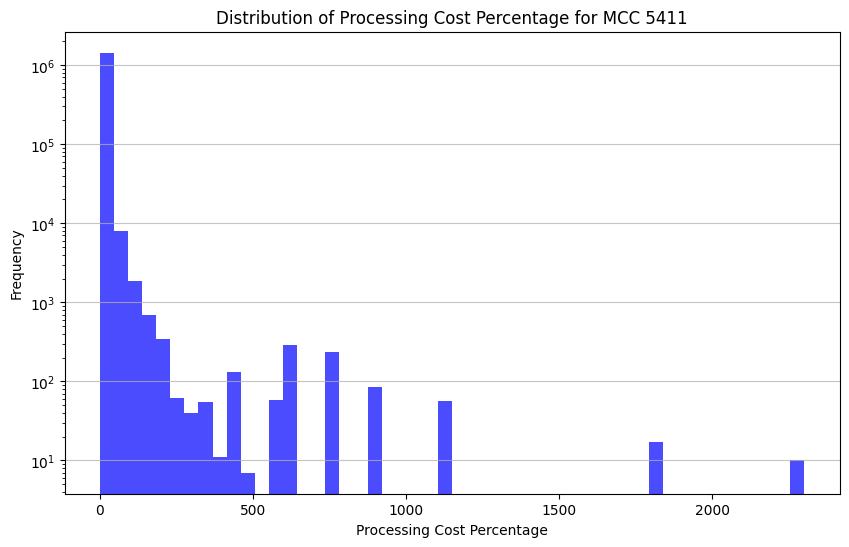

In [15]:
# Distribution of proc_cost_pct
plt.figure(figsize=(10, 6))
plt.hist(df_5411['proc_cost_pct'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Processing Cost Percentage for MCC 5411')
plt.yscale('log')  # Use logarithmic scale for better visibility of distribution
plt.xlabel('Processing Cost Percentage')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [16]:
df_5411.describe()

,date,amount,merchant_id,mcc,cost_type_ID,proc_cost,proc_cost_pct
count,1445853,1.445853e+06,1.445853e+06,1445853.0,1.445853e+06,1.445853e+06,1.445853e+06
mean,2015-01-08 05:13:32.956005888,2.488771e+01,5.651833e+04,5411.0,2.598435e+01,4.475895e-01,5.068616e+00
min,2010-01-01 00:23:00,1.000000e-02,5.000000e+00,5411.0,1.000000e+00,5.019300e-02,2.155762e-01
25%,2012-08-14 06:54:00,4.310000e+00,4.455900e+04,5411.0,1.700000e+01,2.346080e-01,1.833413e+00
50%,2015-01-24 07:02:00,1.120000e+01,5.078300e+04,5411.0,2.600000e+01,2.772320e-01,2.639796e+00
75%,2017-06-14 11:33:00,2.799000e+01,7.578100e+04,5411.0,3.800000e+01,4.164720e-01,4.476703e+00
max,2019-10-31 23:58:00,7.755000e+02,1.003420e+05,5411.0,4.100000e+01,1.317595e+01,2.300180e+03
std,NaN,3.446494e+01,2.610243e+04,0.0,1.221805e+01,4.583776e-01,2.141963e+01


In [17]:
df_5411['year'] = df_5411['date'].dt.year
df_5411['month'] = df_5411['date'].dt.month

df_5411.head()

,transaction_id,date,amount,use_chip,merchant_id,mcc,card_type,mcc_description,card_network,cost_type_ID,proc_cost,proc_cost_pct,year,month
10,7475339,2010-01-01 00:23:00,2.58,Swipe Transaction,75781,5411,debit,"Grocery Stores, Supermarkets",visa,2.0,0.234644,9.094729,2010,1
19,7475349,2010-01-01 00:37:00,20.74,Swipe Transaction,21586,5411,credit,"Grocery Stores, Supermarkets",mastercard,36.0,0.488802,2.356808,2010,1
25,7475357,2010-01-01 00:46:00,4.64,Swipe Transaction,50783,5411,debit,"Grocery Stores, Supermarkets",mastercard,26.0,0.234752,5.059310,2010,1
28,7475360,2010-01-01 00:49:00,2.40,Swipe Transaction,74624,5411,debit,"Grocery Stores, Supermarkets",mastercard,26.0,0.208320,8.680000,2010,1
48,7475388,2010-01-01 01:40:00,2.43,Swipe Transaction,46284,5411,debit,"Grocery Stores, Supermarkets",mastercard,26.0,0.208674,8.587407,2010,1


In [19]:
# group by merchant and month-year to get monthly transaction counts and proc_cost_pct
df_5411_mthly = df_5411.groupby(['merchant_id', 'year','month']).agg(
    transaction_count=('transaction_id', 'count'),
    avg_proc_cost_pct=('proc_cost_pct', 'mean'),
    total_processing_value=('amount', 'sum'),
    median_proc_cost_pct=('proc_cost_pct', 'median')
).reset_index()

df_5411_mthly.head(30)

,merchant_id,year,month,transaction_count,avg_proc_cost_pct,total_processing_value,median_proc_cost_pct
0,5,2011,9,3,3.308678,27.059999,3.470076
1,5,2011,11,1,4.371489,5.640000,4.371489
2,5,2012,12,9,2.213583,145.750000,2.229291
3,20,2013,9,3,4.370629,11.349999,3.807151
4,20,2014,1,1,2.499648,13.640000,2.499648
5,20,2016,4,4,2.357113,79.900002,2.299431
6,34,2017,9,2,5.425364,8.830000,5.425364
7,37,2019,7,1,1.486175,58.790001,1.486175
8,45,2016,6,1,2.529082,13.610000,2.529082
9,54,2019,8,1,3.940736,6.520000,3.940736


In [20]:
sample = df_5411_mthly['merchant_id'].drop_duplicates().sample(n=2000, random_state=42) 
# sample = df_5411_mthly['merchant_id'].drop_duplicates()

sample_merchants = df_5411_mthly[df_5411_mthly['merchant_id'].isin(sample)]

In [21]:
sample_merchants.info()

<class 'pandas.DataFrame'>
Index: 33007 entries, 0 to 131424
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   merchant_id             33007 non-null  int64  
 1   year                    33007 non-null  int32  
 2   month                   33007 non-null  int32  
 3   transaction_count       33007 non-null  int64  
 4   avg_proc_cost_pct       33007 non-null  float64
 5   total_processing_value  33007 non-null  float32
 6   median_proc_cost_pct    33007 non-null  float64
dtypes: float32(1), float64(2), int32(2), int64(2)
memory usage: 1.6 MB


In [22]:
import pandas as pd

# ================================
# Step 0: Setup + Data Hygiene
# ================================

# Ensure consistent dtype
df_5411['cost_type_ID'] = df_5411['cost_type_ID'].astype('float')

# Drop invalid cost types early (critical)
df_5411 = df_5411.dropna(subset=['cost_type_ID'])

# Define full cost type universe (sorted for stability)
all_cost_types = sorted(cost_type_df['cost_type_ID'].dropna().unique())

# ================================
# Step 1: Filter relevant rows
# ================================

keys = sample_merchants[['merchant_id', 'year', 'month']].drop_duplicates()

df_filtered = df_5411.merge(
    keys,
    on=['merchant_id', 'year', 'month'],
    how='inner'
)

# ================================
# Step 2: Group + Count
# ================================

grouped = (
    df_filtered
    .groupby(['merchant_id', 'year', 'month', 'cost_type_ID'], observed=True)
    .size()
    .rename('count')
)

# ================================
# Step 3: Pivot to wide format
# ================================

pivot = grouped.unstack(fill_value=0)

# ================================
# Step 4: Enforce ALL cost types
# ================================

pivot = pivot.reindex(columns=all_cost_types, fill_value=0)

# ================================
# Step 5: Normalize → Percentages
# ================================

row_sums = pivot.sum(axis=1)

# Avoid divide-by-zero: replace 0 with 1 temporarily
pct = pivot.div(row_sums.replace(0, 1), axis=0)

# ================================
# Step 6: Rename columns safely
# ================================

pct.columns = [f'cost_type_{int(col)}_pct' for col in pct.columns]

# ================================
# Step 7: Merge back to base table
# ================================

pct = pct.reset_index()

sample_merchants = sample_merchants.merge(
    pct,
    on=['merchant_id', 'year', 'month'],
    how='left'
)

# ================================
# Step 8: Fill missing rows (no transactions case)
# ================================

pct_cols = [f'cost_type_{int(col)}_pct' for col in all_cost_types]
sample_merchants[pct_cols] = sample_merchants[pct_cols].fillna(0)

# ================================
# Done
# ================================

In [23]:
sample_merchants.info()

<class 'pandas.DataFrame'>
RangeIndex: 33007 entries, 0 to 33006
Data columns (total 68 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   merchant_id             33007 non-null  int64  
 1   year                    33007 non-null  int32  
 2   month                   33007 non-null  int32  
 3   transaction_count       33007 non-null  int64  
 4   avg_proc_cost_pct       33007 non-null  float64
 5   total_processing_value  33007 non-null  float32
 6   median_proc_cost_pct    33007 non-null  float64
 7   cost_type_1_pct         33007 non-null  float64
 8   cost_type_2_pct         33007 non-null  float64
 9   cost_type_3_pct         33007 non-null  float64
 10  cost_type_4_pct         33007 non-null  float64
 11  cost_type_5_pct         33007 non-null  float64
 12  cost_type_6_pct         33007 non-null  float64
 13  cost_type_7_pct         33007 non-null  float64
 14  cost_type_8_pct         33007 non-null  float64
 

In [24]:
# make lag features for proc_cost_pct for each merchant-month

sample_merchants = sample_merchants.sort_values(['merchant_id', 'year', 'month'])
for lag in range(1, 4):
    sample_merchants[f'proc_cost_pct_lag_{lag}'] = sample_merchants.groupby('merchant_id')['avg_proc_cost_pct'].shift(lag)
    
    
sample_merchants['avg_transaction_value'] = sample_merchants['total_processing_value'] / sample_merchants['transaction_count']
    
print(sample_merchants.head(3))

   merchant_id  year  month  transaction_count  avg_proc_cost_pct  \
0            5  2011      9                  3           3.308678   
1            5  2011     11                  1           4.371489   
2            5  2012     12                  9           2.213583   

   total_processing_value  median_proc_cost_pct  cost_type_1_pct  \
0               27.059999              3.470076              0.0   
1                5.640000              4.371489              0.0   
2              145.750000              2.229291              0.0   

   cost_type_2_pct  cost_type_3_pct  ...  cost_type_56_pct  cost_type_57_pct  \
0              0.0              0.0  ...               0.0               0.0   
1              0.0              0.0  ...               0.0               0.0   
2              0.0              0.0  ...               0.0               0.0   

   cost_type_58_pct  cost_type_59_pct  cost_type_60_pct  cost_type_61_pct  \
0               0.0               0.0               

In [25]:
sample_merchants.to_csv('df_5411_merchants_samplemthly_26th_Mar.csv', index=False)

# Helper Functions

In [26]:
# def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months, horizon_len, horizon_max_NAN_months):
#     '''
#     Find ALL valid test scenarios for a given merchant.
    
#     df should be monthly aggregated data with 'merchant_id', 'year', 'month' columns.
    
#     Args:
#         df: Monthly aggregated data (e.g., df_5411_sample)
#         onboard_merchant_id: Merchant ID to find scenario for
#         context_len: Number of months needed for context period
#         context_max_NAN_months: Maximum missing months allowed in context
#         horizon_len: Number of months needed for horizon period
#         horizon_max_NAN_months: Maximum missing months allowed in horizon
    
#     Returns:
#         List of scenarios, each containing:
#             {
#                 'context_data': DataFrame with context period months,
#                 'horizon_data': DataFrame with horizon period months,
#                 'context_range': ((start_year, start_month), (end_year, end_month)),
#                 'horizon_range': ((start_year, start_month), (end_year, end_month)),
#                 'context_gaps': Number of missing months in context,
#                 'horizon_gaps': Number of missing months in horizon
#             }
#     '''
    
#     # Get all months for this merchant
#     merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    
#     if len(merchant_data) == 0:
#         print(f"✗ No data found for merchant {onboard_merchant_id}")
#         return []
    
#     # Sort by year and month
#     merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    
#     print(f"Merchant {onboard_merchant_id} has {len(merchant_data)} month records from {merchant_data.iloc[0]['year']}-{merchant_data.iloc[0]['month']} to {merchant_data.iloc[-1]['year']}-{merchant_data.iloc[-1]['month']}")
    
#     valid_scenarios = []
    
#     # Try each possible starting position for a context window
#     for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
#         # Extract context window (consecutive rows in the merchant_data dataframe)
#         context_end_idx = start_idx + context_len - 1
#         context_window = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)
        
#         # Count actual missing months in context (gaps in calendar)
#         if len(context_window) > 0:
#             context_start = (int(context_window.iloc[0]['year']), int(context_window.iloc[0]['month']))
#             context_end = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            
#             # Calculate expected months between start and end
#             expected_months = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
#             nan_months_context = expected_months - len(context_window)
#         else:
#             nan_months_context = context_len
#             context_start = None
#             context_end = None
        
#         # Check if context is valid
#         if nan_months_context <= context_max_NAN_months and len(context_window) > 0:
#             # Extract horizon window (consecutive rows after context)
#             horizon_start_idx = context_end_idx + 1
#             horizon_end_idx = horizon_start_idx + horizon_len - 1
            
#             # Check if we have enough data for horizon
#             if horizon_end_idx < len(merchant_data):
#                 horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)
                
#                 # Count actual missing months in horizon
#                 if len(horizon_window) > 0:
#                     horizon_start = (int(horizon_window.iloc[0]['year']), int(horizon_window.iloc[0]['month']))
#                     horizon_end = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
                    
#                     # Calculate expected months between start and end
#                     expected_months_h = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
#                     nan_months_horizon = expected_months_h - len(horizon_window)
#                 else:
#                     nan_months_horizon = horizon_len
#                     horizon_start = None
#                     horizon_end = None
                
#                 # Check if horizon is valid
#                 if nan_months_horizon <= horizon_max_NAN_months and len(horizon_window) > 0:
#                     scenario = {
#                         'context_data': context_window,
#                         'horizon_data': horizon_window,
#                         'context_range': (context_start, context_end),
#                         'horizon_range': (horizon_start, horizon_end),
#                         'context_gaps': nan_months_context,
#                         'horizon_gaps': nan_months_horizon
#                     }
#                     valid_scenarios.append(scenario)
    
#     if len(valid_scenarios) > 0:
#         print(f"✓ Found {len(valid_scenarios)} valid scenario(s)")
#     else:
#         print(f"✗ No valid scenario found for merchant {onboard_merchant_id} with context_len={context_len}, horizon_len={horizon_len}")
    
#     return valid_scenarios

In [27]:
# def generate_pool(df, onboard_merchant_id, year, month):
#     '''
#     Generate a pool of transactions for a given merchant and date.
    
#     onboarded merchant is removed from the df and all transactions after the date 
#     are removed to simulate a real-world scenario where we only have 
#     historical data up to the point of onboarding.
#     '''
    
#     pool = df[
#         (df['merchant_id'] != onboard_merchant_id) &
#         ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
        
#     ].copy()
    
#     return pool



In [28]:
# # Helper function to find merchants with enough data for scenarios

# def find_valid_merchants(df, context_len, horizon_len, n_merchants=10):
#     '''
#     Find merchants that have enough consecutive months for both context and horizon periods
#     '''
#     valid_merchants = []
    
#     for merchant_id in df['merchant_id'].unique():
#         merchant_data = df[df['merchant_id'] == merchant_id]
#         merchant_months = merchant_data.groupby(['year', 'month']).size()
        
#         # Check if merchant has enough months for context + horizon
#         if len(merchant_months) >= (context_len + horizon_len):
#             valid_merchants.append(merchant_id)
#             if len(valid_merchants) >= n_merchants:
#                 break
    
#     return valid_merchants


# # Find merchants with enough data
# valid_merchants = find_valid_merchants(sample_merchants, context_len=1, horizon_len=3, n_merchants=5000)
# print(len(valid_merchants))
# # print(str(valid_merchants))


In [29]:
# # Creation of k-NN function to find k similar merchants in pool based on context period features, and use their avg_proc_cost_pct in horizon as prediction for the test merchant's horizon.

# from sklearn.metrics import mean_absolute_error
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import NearestNeighbors

# def get_composite_knn(merchant_context_features, pool_df, k=5):
#     '''
#     find k nearest neighbors based on context period features
    
#     return the pool df rows of the k nearest neighbors as a aggregate merchant feature df
#     '''
    
#     # Extract features and standardize
#     feature_cols = [col for col in pool_df.columns if col not in ['merchant_id', 'year', 'month']]
    
#     # Create copies and fill NaN values (lag features will be NaN for early months, impute with 0)
#     pool_data = pool_df[feature_cols].fillna(0).copy()
#     merchant_data = merchant_context_features[feature_cols].fillna(0).copy()
    
#     # Standardize features
#     scaler = StandardScaler()
#     pool_features_scaled = scaler.fit_transform(pool_data)
#     merchant_features_scaled = scaler.transform(merchant_data)
    
#     # Fit k-NN
#     knn = NearestNeighbors(n_neighbors=min(k, len(pool_data)), metric='euclidean')
#     knn.fit(pool_features_scaled)
    
#     # Find neighbors
#     distances, indices = knn.kneighbors(merchant_features_scaled)
#     neighbor_ids = pool_df.iloc[indices.flatten()]['merchant_id'].values
    
#     # Get the mean of each feature for each month in the pool of neighbors to create a composite feature set for the pool period
#     composite_df = pool_df[pool_df['merchant_id'].isin(neighbor_ids)].copy()
#     # Only average feature columns, not merchant_id
#     composite_df = composite_df.groupby(['year', 'month'])[feature_cols].mean().reset_index()
#     return composite_df


In [30]:
# valid_test_scenarios = []

# for merchant_id in valid_merchants:
#     scenarios = get_test_scenario(sample_merchants, merchant_id, context_len=1, context_max_NAN_months=0, horizon_len=3, horizon_max_NAN_months=0)
#     for scenario in scenarios:
#         valid_test_scenarios.append({
#             'merchant_id': merchant_id,
#             'context_data': scenario['context_data'],
#             'horizon_data': scenario['horizon_data'],
#             'context_range': scenario['context_range'],
#             'horizon_range': scenario['horizon_range'],
#             'context_gaps': scenario['context_gaps'],
#             'horizon_gaps': scenario['horizon_gaps']
#         })